# 15_2 — Walk-forward per-leg sizing (honest test of the pump8/dump3 tilt)

Continuation of `15_kelly_sizing.ipynb` (split out to keep files small). nb15 found the
in-sample per-leg optimum **pump 8% / dump 3%** beats flat 5% on Sharpe *and* growth under
realistic DCA — but it was hand-picked off the whole in-sample grid. Here we test it
honestly: at each time boundary choose `(f_pump, f_dump)` using **only past trades**
(max Sharpe on the trailing window), then trade the next block with it.

The grid is **symmetric** (`f in {2,3,5,8%}` for both legs) so the procedure discovers the
direction itself — if it keeps picking `f_pump > f_dump` out-of-sample, "tilt pump up, dump
down" is real; if erratic, it was overfitting. Same corrected combined book as nb15
(30%/20% catastrophe stop, hold-to-horizon, WF classifier). Evaluated on the **OOS window
only** (from the 40% mark), a fresh $1000+DCA, so every size is judged on strictly-forward data.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

PUMP=pd.read_parquet("_out/pump_rollover.parquet"); DUMP=pd.read_parquet("_out/dump_rollover.parquet")
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]; PUMP_G,DUMP_G=6,6
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
for D in (PUMP,DUMP):
    D["entry"]=naive(D["entry"])
    for i in range(len(GIVEBACKS)): D[f"exit{i}"]=naive(D[f"exit{i}"])
def wf_filter(df,feats,label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return df[(pred>0)|np.isnan(pred)]
pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"],exit_ts=PUMP[f"exit{PUMP_G}"]),PF,"pnl")
dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"],exit_ts=DUMP[f"exit{DUMP_G}"]),DF,"pnl")
NEW=pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream"]],dk[["sym","entry","exit_ts","pnl","liq","stream"]]]).sort_values("entry").reset_index(drop=True)
print(f"combined book: {len(NEW)} trades (pump {(NEW.stream=='pump').sum()} / dump {(NEW.stream=='dump').sum()})")

combined book: 13000 trades (pump 9240 / dump 3760)


In [2]:
# --- lump capacity engine (used to SELECT sizes on trailing data) ---
def run_engine_perleg(df,f_pump,f_dump,n_slots=50,reserve=0.10,cap_frac=0.10,cap_minutes=30,impact=True,start=1000.0):
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; liqs=df.liq.values; strm=df.stream.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        f=f_pump if strm[i]=="pump" else f_dump; want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0.0,avail),cash)
        if cap_frac is not None: no=min(no,cap_frac*liqs[i]*cap_minutes)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec],index=pd.to_datetime([t for t,_ in rec])); daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    return dict(sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan)

# --- realistic DCA engine (nb07); scalar per-leg OR per-trade fraction array ---
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def run_dca(df,ffrac=None,f_pump=0.05,f_dump=0.05,start=1000.,monthly=200.,reserve=0.10,MAX=18,cap=True,slipmodel=True):
    en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]"); bpnl=df.pnl.values; liq=df.liq.values; stream=df.stream.values
    cap_no=PART_CAP*liq*FILL_MIN; months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq="MS")
    cash=start; contrib=start; dep=0.; units=start; openh=[]; mi=0; nav_t=[pd.Timestamp(en.min())]; nav_v=[1.0]; cf=[(-start,pd.Timestamp(en.min()))]; taken=0;capped=0;slip=0.;trec=[]
    def snap(t):
        eq=cash+dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly; cf.append((-monthly,months[mi])); snap(months[mi]); mi+=1
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(_)
        eq=cash+dep; f=ffrac[i] if ffrac is not None else (f_pump if stream[i]=="pump" else f_dump); desired=f*eq
        no=min(desired,cap_no[i]) if cap else desired
        if cap and no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=(SPREAD+IMPACT*part) if slipmodel else 0.0; slip+=no*sl
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl,stream[i])); taken+=1; trec.append((bpnl[i]-sl,no,stream[i]))
    while mi<len(months):
        eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly; cf.append((-monthly,months[mi])); mi+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn); dep-=no; snap(_)
    final=cash+dep; cf.append((final,pd.Timestamp(ex.max())))
    nav=pd.Series(nav_v,index=pd.to_datetime(nav_t)).sort_index(); nav=nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk=pd.DataFrame(trec,columns=["pnl","notional","stream"]); tk["usd"]=tk.notional*tk.pnl
    return dict(final=final,contrib=contrib,nav=nav,taken=taken,capped=capped,slip=slip,tk=tk,cf=cf)
def xirr(cf):
    amts=np.array([a for a,_ in cf]); ds=pd.to_datetime([d for _,d in cf]); t=np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t),-0.999,100)
    except Exception: return np.nan
def metrics(R,tag):
    nav=R["nav"]; span=(nav.index[-1]-nav.index[0]).days/365.25; rr=nav.pct_change().dropna()
    sh=rr.mean()/rr.std()*np.sqrt(365); dd=(nav.values/np.maximum.accumulate(nav.values)-1).min(); cg=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk=R["tk"]
    return dict(config=tag,final=f"${R['final']:,.0f}",mult=f"{R['final']/R['contrib']:.1f}x",IRR=f"{xirr(R['cf'])*100:+.0f}%",CAGR=f"{cg*100:+.0f}%",Sharpe=f"{sh:.2f}",maxDD=f"{dd:.1%}",worst=f"{tk.pnl.min()*100:.0f}%")
print("engines ready")

engines ready


## Walk-forward selection + OOS evaluation

For each block after the first 40%, scan the symmetric grid on the **trailing** trades,
pick the max-Sharpe `(f_pump,f_dump)`, and size that block with it. Then judge everything
on the OOS window (from the 40% mark) as a fresh $1000+DCA.

In [3]:
FPg=[0.02,0.03,0.05,0.08,0.10,0.12,0.15]; FDg=[0.02,0.03,0.05,0.08]
cuts=[int(len(NEW)*q) for q in (0.40,0.55,0.70,0.85,1.0)]
ffwf=np.full(len(NEW),0.05); schedule=[]; prev=cuts[0]
for cut in cuts[1:]:
    trail=NEW.iloc[:prev]; best=None
    for fp in FPg:
        for fd in FDg:
            s=run_engine_perleg(trail,fp,fd)["sharpe"]
            if best is None or s>best[0]: best=(s,fp,fd)
    _,fp,fd=best; schedule.append((prev,cut,fp,fd)); strm=NEW.stream.values[prev:cut]; ffwf[prev:cut]=np.where(strm=="pump",fp,fd); prev=cut
print("walk-forward per-leg picks (each chosen on PAST trades only):")
for a,b,fp,fd in schedule:
    lab = "pump>dump  <-- tilt confirmed" if fp>fd else ("pump=dump" if fp==fd else "pump<dump")
    print(f"  [{NEW.entry.iloc[a].date()}..{NEW.entry.iloc[b-1].date()}]  pump {fp:.0%} / dump {fd:.0%}   {lab}")

c0=cuts[0]; oos=NEW.iloc[c0:].reset_index(drop=True); ffwf_oos=ffwf[c0:]
res=[metrics(run_dca(oos,f_pump=0.03,f_dump=0.03),"flat 3%"),
     metrics(run_dca(oos,f_pump=0.05,f_dump=0.05),"flat 5% (bot)"),
     metrics(run_dca(oos,f_pump=0.08,f_dump=0.03),"pump8/dump3 (in-sample pick)"),
     metrics(run_dca(oos,ffrac=ffwf_oos),"walk-forward per-leg (honest)")]
print(f"\nOOS window {oos.entry.min().date()}..{oos.entry.max().date()}  ({len(oos)} trades) - realistic DCA:")
print(pd.DataFrame(res)[["config","final","mult","CAGR","Sharpe","maxDD","worst"]].to_string(index=False))

walk-forward per-leg picks (each chosen on PAST trades only):
  [2024-06-14..2024-11-23]  pump 8% / dump 8%   pump=dump
  [2024-11-23..2025-04-07]  pump 8% / dump 8%   pump=dump
  [2025-04-07..2025-10-13]  pump 8% / dump 2%   pump>dump  <-- tilt confirmed
  [2025-10-13..2026-04-30]  pump 8% / dump 3%   pump>dump  <-- tilt confirmed



OOS window 2024-06-14..2026-04-30  (7800 trades) - realistic DCA:
                       config   final mult  CAGR Sharpe  maxDD worst
                      flat 3% $17,263 3.1x +125%   3.56 -10.5%  -37%
                flat 5% (bot) $27,589 4.9x +210%   3.16 -18.0%  -37%
 pump8/dump3 (in-sample pick) $37,246 6.7x +283%   3.47 -21.7%  -37%
walk-forward per-leg (honest) $34,362 6.1x +268%   3.34 -25.3%  -37%


[saved] notebooks\pump_dump_combined\_out\comb_15_2_wf.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_15_2_wf.png')

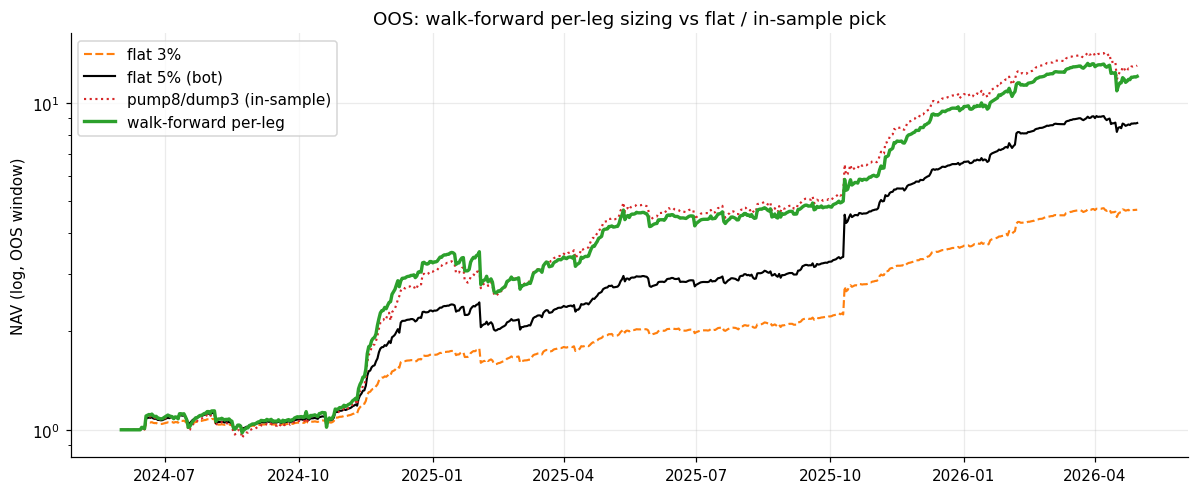

In [4]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(11,4.6))
for (fp,fd,tag),style in zip([(0.03,0.03,"flat 3%"),(0.05,0.05,"flat 5% (bot)"),(0.08,0.03,"pump8/dump3 (in-sample)")],["C1--","k-","C3:"]):
    nav=run_dca(oos,f_pump=fp,f_dump=fd)["nav"]; ax.plot(nav.index,nav.values,style,lw=1.4,label=tag)
nav=run_dca(oos,ffrac=ffwf_oos)["nav"]; ax.plot(nav.index,nav.values,"C2-",lw=2.2,label="walk-forward per-leg")
ax.set_yscale("log"); ax.set_ylabel("NAV (log, OOS window)"); ax.set_title("OOS: walk-forward per-leg sizing vs flat / in-sample pick"); ax.legend()
show("comb_15_2_wf")

In [5]:
# does pump want MORE than 8%? sweep pump fraction (dump fixed 3%) on the OOS window
sw=[]
for fp in [0.05,0.08,0.10,0.12,0.15]:
    sw.append(metrics(run_dca(oos,f_pump=fp,f_dump=0.03),f"pump {fp:.0%} / dump 3%"))
print("OOS DCA — pump-fraction sweep at dump=3% (is 8% a peak or a ceiling?):")
print(pd.DataFrame(sw)[["config","mult","CAGR","Sharpe","maxDD","worst"]].to_string(index=False))

OOS DCA — pump-fraction sweep at dump=3% (is 8% a peak or a ceiling?):
            config mult  CAGR Sharpe  maxDD worst
 pump 5% / dump 3% 4.5x +191%   3.61 -14.2%  -37%
 pump 8% / dump 3% 6.7x +283%   3.47 -21.7%  -37%
pump 10% / dump 3% 7.8x +329%   3.28 -27.1%  -37%
pump 12% / dump 3% 8.8x +365%   3.11 -30.6%  -37%
pump 15% / dump 3% 8.9x +375%   2.83 -35.1%  -37%


In [6]:
# 4-tier mode ladder for the spec (dump fixed 3%, pump = the dial), OOS DCA
tiers=[("conservative",0.03,0.03),("medium",0.04,0.03),("aggressive",0.05,0.03),("super-aggressive",0.08,0.03)]
print("mode ladder (dump=3%, OOS DCA window):")
print(pd.DataFrame([metrics(run_dca(oos,f_pump=fp,f_dump=fd),f"{nm}  pump{fp:.0%}/dump{fd:.0%}") for nm,fp,fd in tiers])[["config","mult","CAGR","Sharpe","maxDD","worst"]].to_string(index=False))

mode ladder (dump=3%, OOS DCA window):


                         config mult  CAGR Sharpe  maxDD worst
    conservative  pump3%/dump3% 3.1x +125%   3.56 -10.5%  -37%
          medium  pump4%/dump3% 3.8x +160%   3.65 -12.0%  -37%
      aggressive  pump5%/dump3% 4.5x +191%   3.61 -14.2%  -37%
super-aggressive  pump8%/dump3% 6.7x +283%   3.47 -21.7%  -37%


## Verdict — widening the grid clarifies it: the robust win is trimming DUMP; pump size is just a growth dial

**1. WF does not chase ever-higher pump.** With the grid open to 15%, walk-forward still
picks **pump 8% in every block** (never 10/12/15%) and still trims dump to 2-3%. OOS result
unchanged (6.1x / Sharpe 3.34, > flat 5%). So it is not pinned at a ceiling.

**2. But pump 8% is NOT the Sharpe peak.** The pump-sweep at dump=3% (above) shows Sharpe is
highest at **pump ~5% (3.61)** and falls monotonically as pump rises (8%->3.47, 10%->3.28,
15%->2.83), while growth keeps climbing (4.5x->8.9x) and drawdown explodes (-14%->-35%).
So **raising pump is a pure growth-for-drawdown trade, not a risk-adjusted gain** — WF's 8%
is trailing-optimal but a touch aggressive vs the forward Sharpe ideal (~5%). More pump = more
money and worse Sharpe/DD; there is no free lunch up the pump axis.

**3. The genuinely robust, risk-adjusted win is the DUMP TRIM.** pump5/dump3 beats flat 5%
(=pump5/dump5) on **both** Sharpe (3.61 vs 3.16) **and** drawdown (-14.2% vs -18.0%) at
nearly the same growth (4.5x vs 4.9x). Cutting the high-variance dump leg from 5% to 3% is
close to a free lunch — and it agrees with step-3's lump-sum grid (Sharpe-optimum also
pump5/dump3). Pushing pump up is optional leverage layered on top of that.

**Recommendation (refined):**
- **Best risk-adjusted aggressive:** **pump ~5% / dump ~3%** (just trim dump) — strictly
  better than your flat 5% on Sharpe and drawdown, ~same money.
- **Want maximum growth:** raise pump (WF's 8% -> 6.7x/DD-22%, up to 15% -> 8.9x/DD-35%),
  accepting lower Sharpe and deeper drawdown — a volume knob, not an edge.
- **Conservative:** flat ~3% (Sharpe 3.56 / DD -10.5%).

**Robust takeaway across lump / DCA / walk-forward: trim dump to ~3%. Pump size is a
growth<->drawdown dial, with the Sharpe sweet spot near 5%, not 8%.**

Caveats: worst trade -37% at every setting (dump gap tail = catastrophe-stop's job, sizing
never touches it); one in-sample period/universe, no true alt-mania; entry-slippage at the
crash trough unmodeled. The -14% (5/3) to -35% (15/3) drawdowns are the honest live risk.